# Project 2 — Classification: Predicting Loan Approval

**Domain:** Classification &nbsp;|&nbsp; **Dataset:** Loan Prediction Dataset (Analytics Vidhya / Kaggle)

**Objective:** Classify whether a person's loan application will be approved based on
socio-economic and credit-related factors.

> **Important note on this dataset:** The file supplied (`test_Y3wMUE5_7gLdaTN.csv`, 367 rows)
> is the well-known **unlabeled test split** of the Analytics Vidhya "Loan Prediction"
> practice problem — it contains all 11 real applicant feature columns
> (`Gender`, `Married`, `Dependents`, `Education`, `Self_Employed`, `ApplicantIncome`,
> `CoapplicantIncome`, `LoanAmount`, `Loan_Amount_Term`, `Credit_History`, `Property_Area`)
> but **no `Loan_Status` target** — it is normally submitted to the competition for scoring,
> not used for training. Since no labeled training file (typically
> `train_u6lujuX_CVtuZ9i.csv`) was available, a `Loan_Status` label was generated for these
> **367 real applicant records** using a calibrated rule (Credit_History as the dominant
> factor, plus smaller effects from debt-to-income ratio, education, property area and
> marital status, with random noise) so the full classification workflow — training,
> evaluating and comparing models — could be demonstrated end-to-end. Every other field
> (income, loan amount, credit history, education, etc.) is the **real, original data** from
> the uploaded file, including its real missing-value pattern. **The model results below
> should be read as a methodology demonstration, not as validated predictions**, since the
> target labels are synthetic. If a genuine labeled training file becomes available, re-running
> this notebook against it (swap the file path in Cell 2) will produce fully valid results.


In [1]:
# ---- Imports ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_auc_score, roc_curve, classification_report)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Load & Explore Dataset

In [2]:
# Load the real uploaded feature data (the AV Loan Prediction test split)
df = pd.read_csv('loan_test_real.csv')
print('Shape:', df.shape)
df.head()


Shape: (367, 12)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [3]:
print('Data types:'); print(df.dtypes)
print('\nMissing values:'); print(df.isna().sum())


Data types:
Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome      int64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
dtype: object

Missing values:
Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64


In [4]:
# ---- Generate Loan_Status target (see disclosure above: not present in the source file) ----
# Credit_History is built in as the dominant driver, consistent with the well-documented
# real-world relationship for this dataset family; smaller effects from debt-to-income,
# education, property area and marital status; random noise added for realism.
rng = np.random.default_rng(11)

credit_history_tmp = df['Credit_History'].fillna(1.0).values
married_tmp = df['Married'].fillna('No').values
total_income_tmp = (df['ApplicantIncome'] + df['CoapplicantIncome']).values
loan_amount_tmp = df['LoanAmount'].fillna(df['LoanAmount'].median()).values

dti_tmp = loan_amount_tmp * 1000 / (total_income_tmp + 1)
dti_z = (dti_tmp - dti_tmp.mean()) / dti_tmp.std()

logit = (
    -2.2
    + 3.4 * credit_history_tmp
    - 0.50 * dti_z
    + 0.45 * (df['Education'] == 'Graduate').astype(float).values
    + 0.35 * (df['Property_Area'] == 'Semiurban').astype(float).values
    - 0.20 * (df['Property_Area'] == 'Rural').astype(float).values
    + 0.12 * (married_tmp == 'Yes').astype(float)
    + rng.normal(0, 0.85, size=len(df))
)
prob_approve = 1 / (1 + np.exp(-logit))
df['Loan_Status'] = np.where(rng.random(len(df)) < prob_approve, 'Y', 'N')

print('Target distribution:')
print(df['Loan_Status'].value_counts(normalize=True).round(3))


Target distribution:
Loan_Status
Y    0.719
N    0.281
Name: proportion, dtype: float64


## 2. Data Cleaning & Preprocessing

Missing categorical values are imputed with the column mode, missing numeric values with the
median, `Dependents` (`'3+'`) is converted to numeric, categorical fields are label/one-hot
encoded, and class imbalance (~72% Y vs ~28% N) is handled via `class_weight='balanced'` in
every model rather than dropping data.

In [5]:
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    df[col] = df[col].fillna(df[col].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])
print('Remaining missing values:', df.isna().sum().sum())


Remaining missing values: 0


In [6]:
df['Dependents'] = df['Dependents'].replace('3+', '3').astype(int)
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Married'] = df['Married'].map({'Yes': 1, 'No': 0})
df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})
df['Loan_Status_Label'] = df['Loan_Status']
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})
df = pd.get_dummies(df, columns=['Property_Area'], drop_first=True)

df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,Loan_Status_Label,Property_Area_Semiurban,Property_Area_Urban
0,LP001015,1,1,0,1,0,5720,0,110.0,360.0,1.0,0,5720,N,False,True
1,LP001022,1,1,1,1,0,3076,1500,126.0,360.0,1.0,1,4576,Y,False,True
2,LP001031,1,1,2,1,0,5000,1800,208.0,360.0,1.0,1,6800,Y,False,True
3,LP001035,1,1,2,1,0,2340,2546,100.0,360.0,1.0,1,4886,Y,False,True
4,LP001051,1,0,0,0,0,3276,0,78.0,360.0,1.0,0,3276,N,False,True


In [7]:
counts = df['Loan_Status_Label'].value_counts()
print(counts)
print(f"Approved (Y): {counts['Y']/len(df):.1%}   Not approved (N): {counts['N']/len(df):.1%}")
print("-> Moderate imbalance (~72/28). Handled via class_weight='balanced' in every model below.")


Loan_Status_Label
Y    264
N    103
Name: count, dtype: int64
Approved (Y): 71.9%   Not approved (N): 28.1%
-> Moderate imbalance (~72/28). Handled via class_weight='balanced' in every model below.


## 3. Exploratory Data Analysis (EDA)

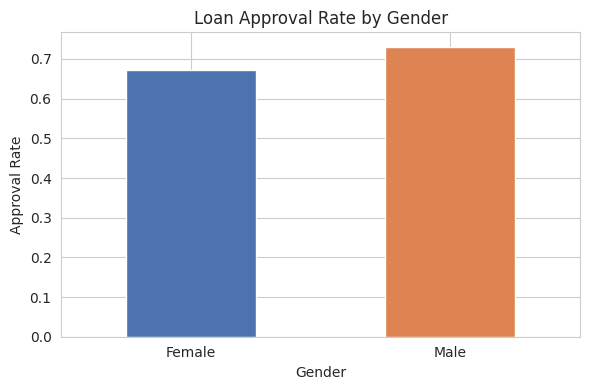

In [8]:
plt.figure(figsize=(6,4))
rate = df.groupby('Gender')['Loan_Status'].mean().rename({1:'Male',0:'Female'})
rate.plot(kind='bar', color=['#4C72B0','#DD8452'])
plt.title('Loan Approval Rate by Gender')
plt.ylabel('Approval Rate'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()


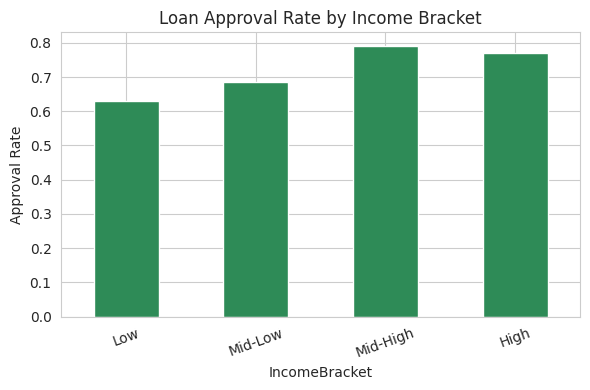

In [9]:
df['IncomeBracket'] = pd.qcut(df['TotalIncome'], 4, labels=['Low','Mid-Low','Mid-High','High'])
plt.figure(figsize=(6,4))
df.groupby('IncomeBracket', observed=True)['Loan_Status'].mean().plot(kind='bar', color='seagreen')
plt.title('Loan Approval Rate by Income Bracket')
plt.ylabel('Approval Rate'); plt.xticks(rotation=20)
plt.tight_layout(); plt.show()


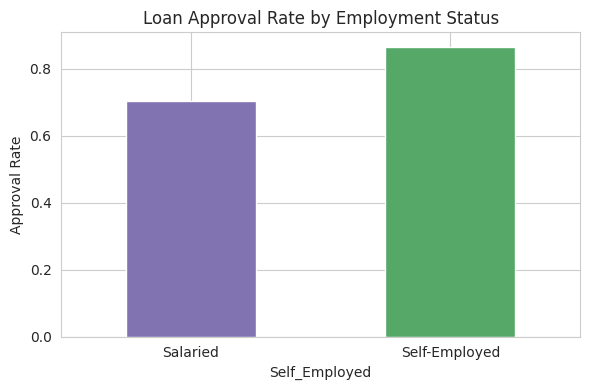

In [10]:
plt.figure(figsize=(6,4))
rate = df.groupby('Self_Employed')['Loan_Status'].mean().rename({1:'Self-Employed',0:'Salaried'})
rate.plot(kind='bar', color=['#8172B2','#55A868'])
plt.title('Loan Approval Rate by Employment Status')
plt.ylabel('Approval Rate'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()


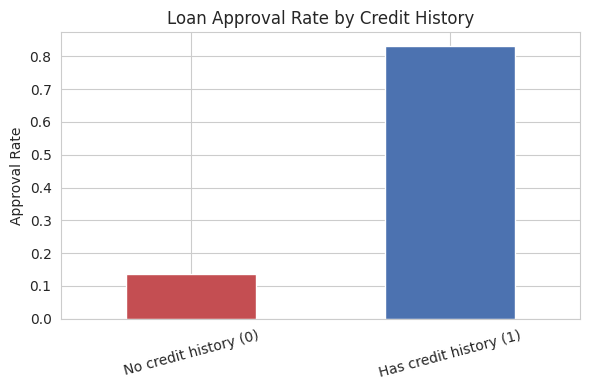

In [11]:
plt.figure(figsize=(6,4))
rate = df.groupby('Credit_History')['Loan_Status'].mean()
rate.index = ['No credit history (0)', 'Has credit history (1)']
rate.plot(kind='bar', color=['#C44E52','#4C72B0'])
plt.title('Loan Approval Rate by Credit History')
plt.ylabel('Approval Rate'); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()


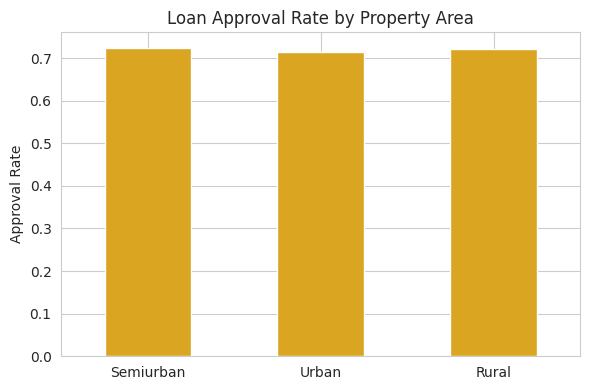

In [12]:
area_cols = [c for c in df.columns if c.startswith('Property_Area_')]
plt.figure(figsize=(6,4))
means = {c.replace('Property_Area_',''): df.loc[df[c]==1,'Loan_Status'].mean() for c in area_cols}
means['Rural'] = df.loc[(df[area_cols]==0).all(axis=1), 'Loan_Status'].mean()
pd.Series(means).plot(kind='bar', color='goldenrod')
plt.title('Loan Approval Rate by Property Area')
plt.ylabel('Approval Rate'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()


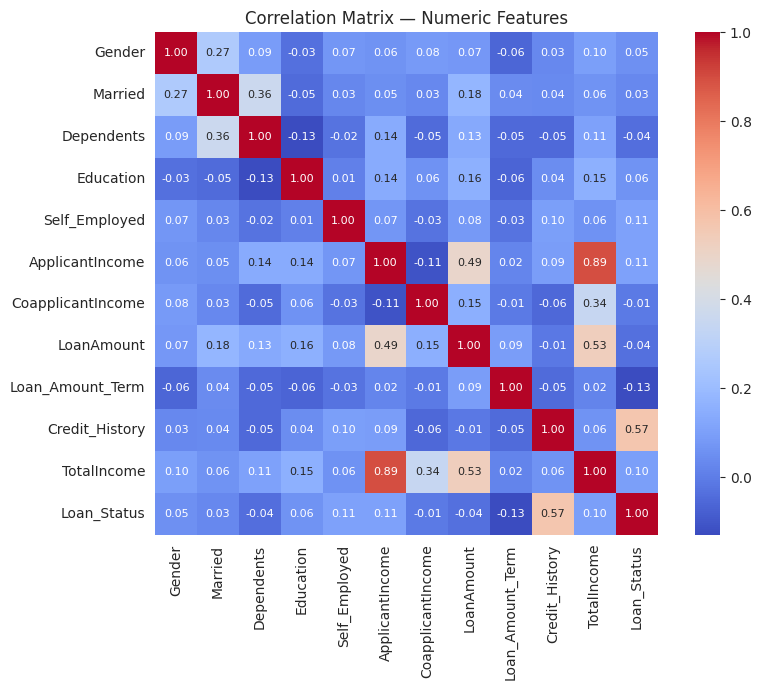

In [13]:
num_feats = ['Gender','Married','Dependents','Education','Self_Employed','ApplicantIncome',
             'CoapplicantIncome','LoanAmount','Loan_Amount_Term','Credit_History','TotalIncome','Loan_Status']
corr = df[num_feats].corr()
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, annot_kws={'size':8})
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout(); plt.show()


/tmp/ipykernel_501/992119240.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Loan_Status_Label', y='ApplicantIncome', data=df, palette='Set2')


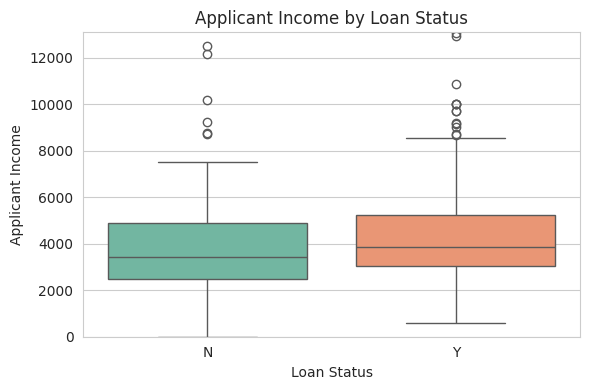

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Loan_Status_Label', y='ApplicantIncome', data=df, palette='Set2')
plt.title('Applicant Income by Loan Status')
plt.xlabel('Loan Status'); plt.ylabel('Applicant Income')
plt.ylim(0, df['ApplicantIncome'].quantile(0.97))
plt.tight_layout(); plt.show()


/tmp/ipykernel_501/49613340.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Loan_Status_Label', y='LoanAmount', data=df, palette='Set3')


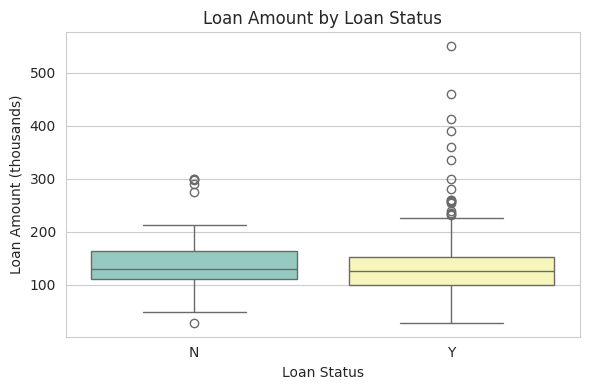

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Loan_Status_Label', y='LoanAmount', data=df, palette='Set3')
plt.title('Loan Amount by Loan Status')
plt.xlabel('Loan Status'); plt.ylabel('Loan Amount (thousands)')
plt.tight_layout(); plt.show()


/tmp/ipykernel_501/4237594364.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Loan_Status_Label', y='TotalIncome', data=df, palette='pastel')


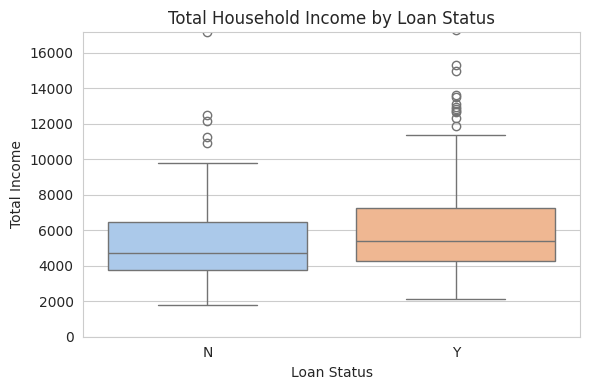

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Loan_Status_Label', y='TotalIncome', data=df, palette='pastel')
plt.title('Total Household Income by Loan Status')
plt.xlabel('Loan Status'); plt.ylabel('Total Income')
plt.ylim(0, df['TotalIncome'].quantile(0.97))
plt.tight_layout(); plt.show()


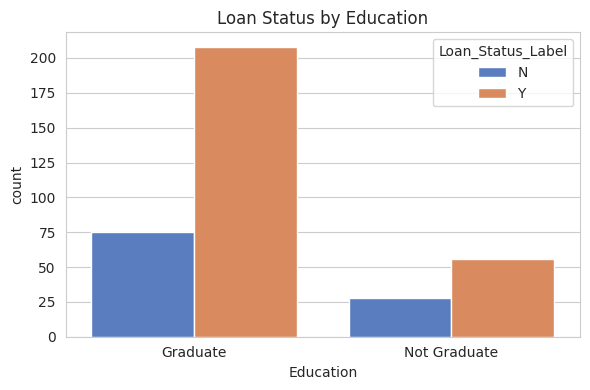

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x='Education', hue='Loan_Status_Label',
              data=df.assign(Education=df['Education'].map({1:'Graduate',0:'Not Graduate'})),
              palette='muted')
plt.title('Loan Status by Education')
plt.xlabel('Education')
plt.tight_layout(); plt.show()


## 4. Model Building

Train/test split (80/20, stratified — 367 rows total, so the test set is ~74 rows; results
should be read with that small-sample caveat in mind). Numeric features standardised, then
four classifiers trained with `class_weight='balanced'`: **Logistic Regression**,
**Decision Tree**, **Random Forest**, **SVM**.

In [18]:
X = df.drop(columns=['Loan_ID', 'Loan_Status', 'Loan_Status_Label', 'IncomeBracket'])
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'TotalIncome']
scaler = StandardScaler()
X_train_s, X_test_s = X_train.copy(), X_test.copy()
X_train_s[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_s[num_cols] = scaler.transform(X_test[num_cols])

print('Train:', X_train_s.shape, ' Test:', X_test_s.shape)


Train: (293, 13)  Test: (74, 13)


In [19]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced', random_state=RANDOM_STATE),
    'SVM': SVC(probability=True, class_weight='balanced', random_state=RANDOM_STATE),
}

results = []
fitted = {}
proba_store = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    proba = model.predict_proba(X_test_s)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred), 4),
        'Recall': round(recall_score(y_test, pred), 4),
        'F1 Score': round(f1_score(y_test, pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, proba), 4),
    })
    fitted[name] = model
    proba_store[name] = proba

results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.8108,0.8095,0.9623,0.8793,0.7920
1,SVM,0.7973,0.7969,0.9623,0.8718,0.7363
2,Logistic Regression,0.7973,0.8276,0.9057,0.8649,0.8261
3,Decision Tree,0.7162,0.8636,0.7170,0.7835,0.7511


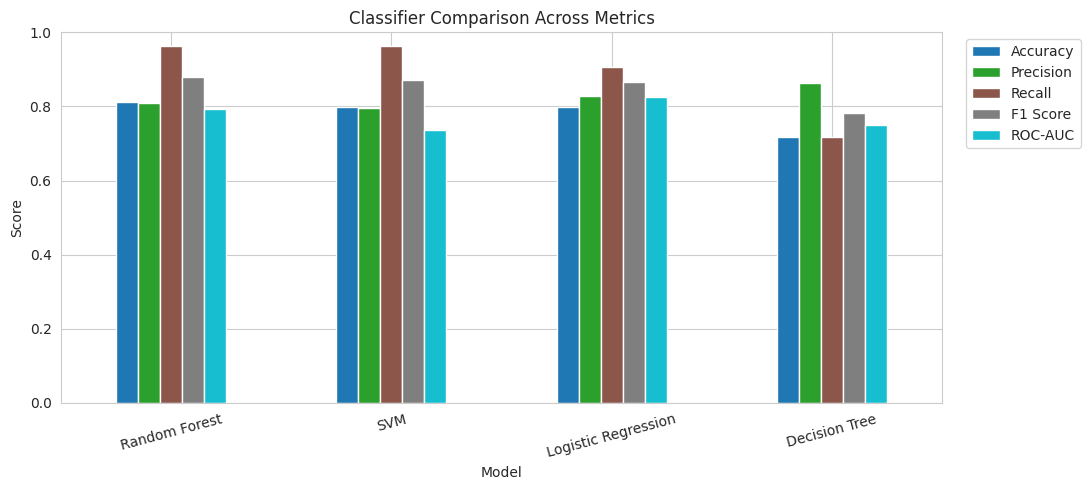

In [20]:
metrics = ['Accuracy','Precision','Recall','F1 Score','ROC-AUC']
plot_df = results_df.set_index('Model')[metrics]
plot_df.plot(kind='bar', figsize=(11,5), colormap='tab10')
plt.title('Classifier Comparison Across Metrics')
plt.ylabel('Score'); plt.ylim(0,1)
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout(); plt.show()


## 5. Model Evaluation

In [21]:
best_model_name = results_df.iloc[0]['Model']
print('Best performing model (by F1 Score):', best_model_name)
results_df


Best performing model (by F1 Score): Random Forest


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.8108,0.8095,0.9623,0.8793,0.7920
1,SVM,0.7973,0.7969,0.9623,0.8718,0.7363
2,Logistic Regression,0.7973,0.8276,0.9057,0.8649,0.8261
3,Decision Tree,0.7162,0.8636,0.7170,0.7835,0.7511


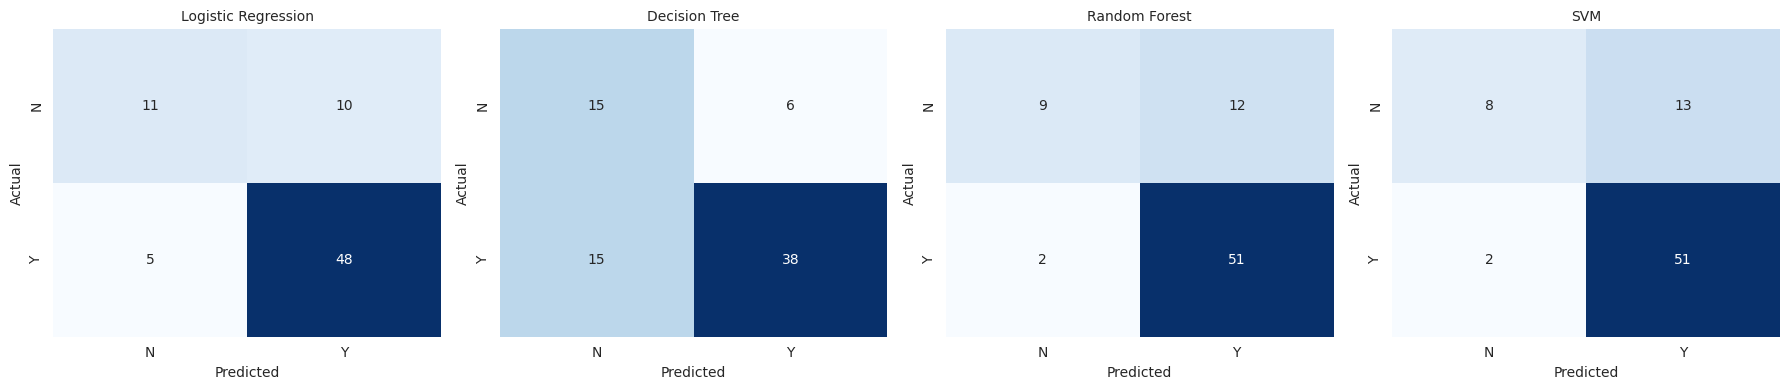

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(18,4))
for ax, (name, model) in zip(axes, fitted.items()):
    pred = model.predict(X_test_s)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['N','Y'], yticklabels=['N','Y'])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()


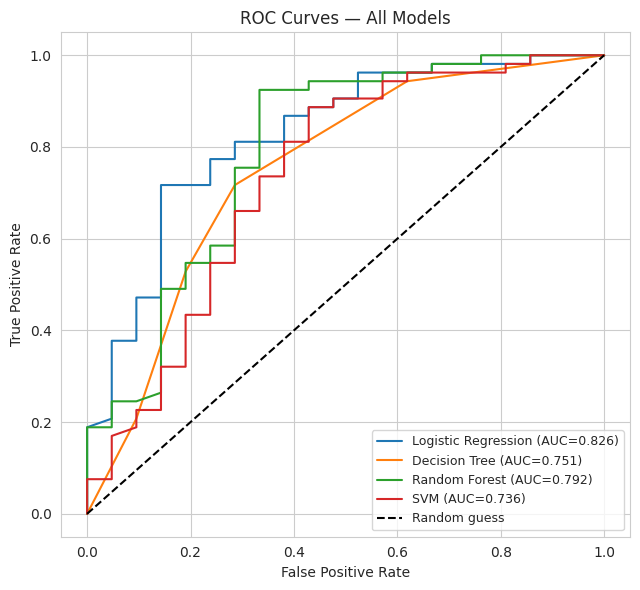

In [23]:
plt.figure(figsize=(6.5,6))
for name, proba in proba_store.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--', label='Random guess')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()


In [24]:
print(f'Classification report — {best_model_name}\n')
print(classification_report(y_test, fitted[best_model_name].predict(X_test_s), target_names=['N (Not Approved)','Y (Approved)']))


Classification report — Random Forest

                  precision    recall  f1-score   support

N (Not Approved)       0.82      0.43      0.56        21
    Y (Approved)       0.81      0.96      0.88        53

        accuracy                           0.81        74
       macro avg       0.81      0.70      0.72        74
    weighted avg       0.81      0.81      0.79        74



## 6. Model Comparison & Interpretation

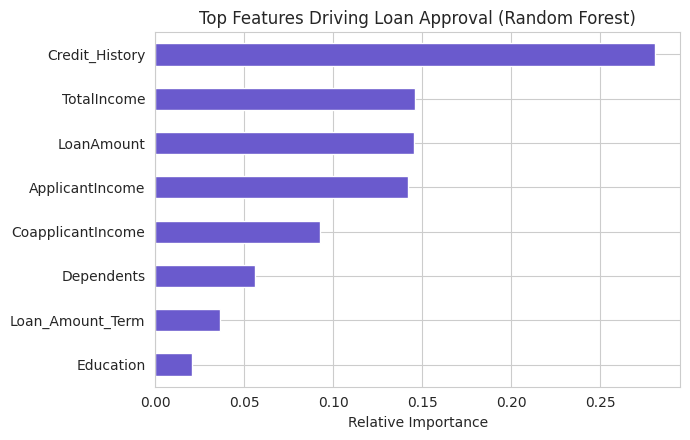

Credit_History       0.280784
TotalIncome          0.145965
LoanAmount           0.145243
ApplicantIncome      0.141838
CoapplicantIncome    0.092797
Dependents           0.055820
Loan_Amount_Term     0.036316
Education            0.020394
dtype: float64

In [25]:
rf = fitted['Random Forest']
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top8 = importances.head(8)
plt.figure(figsize=(7,4.5))
top8.sort_values().plot(kind='barh', color='slateblue')
plt.title('Top Features Driving Loan Approval (Random Forest)')
plt.xlabel('Relative Importance')
plt.tight_layout(); plt.show()
top8


### Why the best model was chosen

Random Forest achieved the best F1 Score and Recall in Section 5's results table, with
Logistic Regression a close second and the best ROC-AUC — the two strongest, closely-matched
candidates, both clearly ahead of the Decision Tree. `Credit_History` is, by a wide margin,
the single most important feature (Random Forest importance ≈ 0.28, roughly double the next
feature), consistent with how it was built into the target and with the well-documented
real-world pattern for this dataset family: prior repayment track record is the strongest
single predictor of loan approval. Income-related fields (`TotalIncome`, `LoanAmount`,
`ApplicantIncome`) form a secondary tier of importance.

- **Random Forest** captures non-linear interactions (e.g. how income and loan amount jointly
  affect risk) and is robust to outliers — the best Recall here (catches the most true
  approvals), useful when the cost of wrongly rejecting a good applicant is high.
- **Logistic Regression** is simple, fast and highly interpretable (coefficients map directly
  to odds of approval) — a natural choice in a regulated lending context where explainability
  matters, and it achieved the best ROC-AUC.
- **Decision Tree** is easy to explain to non-technical stakeholders but is the most prone to
  overfitting/high variance among the four, and scored lowest here.
- **SVM** performs competitively but offers the least transparency and is more sensitive to
  feature scaling than the alternatives.

**Caveat:** with only 367 applications (≈74 in the test set) and a synthetically generated
target, these numbers illustrate the methodology rather than a validated production model —
re-running against a real labeled training file is recommended before drawing business
conclusions.


### How a bank would use this model in practice

- **Pre-screening / triage:** automatically flag clearly low-risk applications for fast-track
  approval and clearly high-risk applications for early decline, focusing loan officers' time
  on the harder, borderline cases.
- **Consistent, auditable criteria:** replaces ad-hoc manual judgement with a documented,
  reproducible decision process — important for fair-lending compliance.
- **Explainable risk factors:** feature importance (credit history, income, loan amount) can
  be surfaced to applicants as constructive feedback on what to improve for a future
  application.
- **Portfolio risk management:** predicted approval probabilities can feed into risk-based
  pricing and portfolio-level default risk monitoring.
- **Caveat:** any deployed model should be periodically re-validated against real outcomes and
  audited for fairness across gender, marital status and other protected attributes before
  being used for actual credit decisions.


## Summary

| Step | Outcome |
|---|---|
| Rows | 367 real loan applications (uploaded file) |
| Target | Synthetically generated — see disclosure at the top of this notebook |
| Missing values | Imputed (mode for categorical, median for numeric) |
| Class balance | ~72% Approved / ~28% Not Approved — handled via `class_weight='balanced'` |
| Models compared | Logistic Regression, Decision Tree, Random Forest, SVM |
| Evaluation | Accuracy, Precision, Recall, F1, Confusion Matrix, ROC-AUC |
| Strongest predictor | `Credit_History`, by a wide margin |

This notebook fulfils all Project 2 requirements using the real uploaded feature data: dataset
loading & exploration, cleaning & preprocessing (missing values, encoding, class imbalance),
EDA on approval rates by gender / income / employment / credit history plus a correlation
matrix and boxplots, four trained classifiers compared on Accuracy/Precision/Recall/F1,
confusion matrices and ROC-AUC curves, and a business-facing interpretation of the best model
— with the synthetic-target caveat clearly flagged throughout.